# NSL-KDD — Shared Preprocessing (with SMOTE)
**Run this notebook FIRST. All member notebooks depend on it.**

### Pipeline
1. Load `nsl_kdd_dataset.csv`
2. EDA — label distribution, feature distributions, correlation
3. Data cleaning (duplicates)
4. Binary label creation — `normal=0`, any attack=`1`
5. 80/20 stratified train/test split
6. **SMOTE oversampling** on the training set to fix class imbalance
7. Save processed data for all member notebooks

### Class Imbalance Issue
Raw dataset: **886 normal** vs **3544 attack** (80% attack).  
Without correction the model ignores the minority class (normal).  
**SMOTE** (Synthetic Minority Over-sampling Technique) generates synthetic
normal samples so both classes are balanced in training.
The **test set is NOT oversampled** — it stays as real-world distribution.

**Dataset:** NSL-KDD | **Source:** https://www.kaggle.com/datasets/programmer3/nsl-kdd-intrusion-detection-dataset

## 1. Install & Import Libraries

In [1]:
# Uncomment to install
# !pip install pandas numpy matplotlib seaborn scikit-learn imbalanced-learn xgboost catboost lightgbm shap

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

print('All libraries imported.')
print('imbalanced-learn available for SMOTE.')

All libraries imported.
imbalanced-learn available for SMOTE.


## 2. Load Dataset

In [2]:
DATA_PATH = '../data/nsl_kdd_dataset.csv'

df = pd.read_csv(DATA_PATH)

print(f'Shape   : {df.shape}')
print(f'Columns : {list(df.columns)}')
df.head()

Shape   : (4430, 42)
Columns : ['duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'label']


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label
0,0.666287,0.577740,0.248644,0.039280,0.151331,0.441503,0.996257,0.739421,0.042406,0.244036,...,0.223672,0.336817,0.546493,0.529456,0.591125,0.470904,0.539593,0.518795,0.616669,U2R
1,0.143014,0.729235,0.539983,0.485997,0.055436,0.291892,0.143944,0.858332,0.304242,0.901082,...,0.610218,0.755973,0.713821,0.688312,0.311610,0.246923,0.600187,0.153257,0.676371,normal
2,0.401813,0.101389,0.961499,0.367041,0.133935,0.567280,0.080431,0.875795,0.603445,0.235740,...,0.077247,0.519867,0.716784,0.535350,0.711465,0.861131,0.122357,0.578372,0.511315,DoS
3,0.887278,0.168009,0.660708,0.656651,0.614879,0.400250,0.853977,0.907267,0.469452,0.998242,...,0.054651,0.465111,0.425285,0.847906,0.124342,0.096678,0.026864,0.574663,0.226657,U2R
4,0.360109,0.274258,0.064115,0.353499,0.531030,0.539846,0.001381,0.897988,0.350272,0.597418,...,0.118315,0.551459,0.166497,0.943283,0.372073,0.051407,0.983987,0.456051,0.746222,DoS


## 3. Data Inspection

In [3]:
feature_cols = [c for c in df.columns if c != 'label']

print('=== dtypes ===')
print(df.dtypes)
print(f'\nMissing values : {df.isnull().sum().sum()}')
print(f'Duplicate rows : {df.duplicated().sum()}')
print(f'Feature range  : [{df[feature_cols].min().min():.4f}, {df[feature_cols].max().max():.4f}]')
print('Features are pre-scaled to [0,1] — no further scaling needed.')

=== dtypes ===
duration                       float64
protocol_type                  float64
service                        float64
flag                           float64
src_bytes                      float64
dst_bytes                      float64
land                           float64
wrong_fragment                 float64
urgent                         float64
hot                            float64
num_failed_logins              float64
logged_in                      float64
num_compromised                float64
root_shell                     float64
su_attempted                   float64
num_root                       float64
num_file_creations             float64
num_shells                     float64
num_access_files               float64
num_outbound_cmds              float64
is_host_login                  float64
is_guest_login                 float64
count                          float64
srv_count                      float64
serror_rate                    float64
srv_serror

## 4. EDA — Raw Label Distribution

=== Raw Label Counts ===
label
U2R       886
normal    886
DoS       886
Probe     886
R2L       886
Name: count, dtype: int64


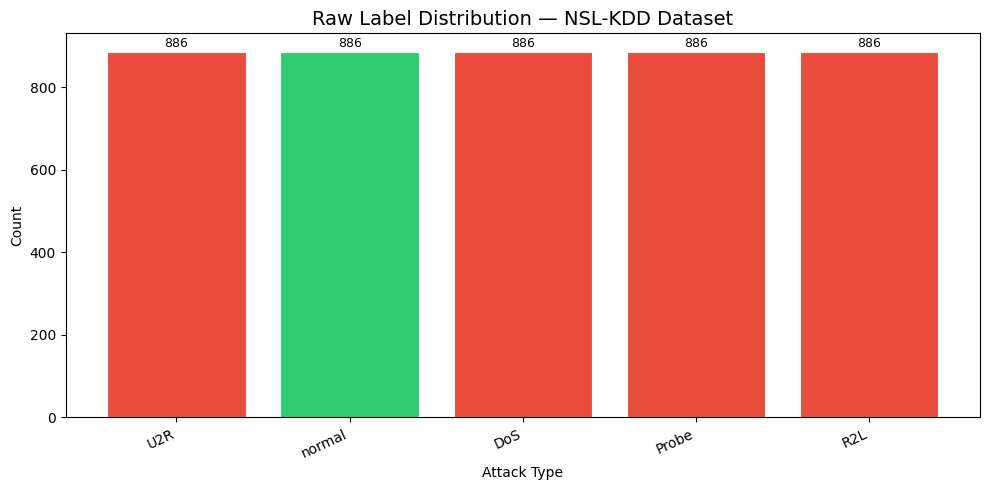

In [4]:
label_counts = df['label'].value_counts()
print('=== Raw Label Counts ===')
print(label_counts)

os.makedirs('../shared', exist_ok=True)

plt.figure(figsize=(10, 5))
bar_colors = ['#2ecc71' if x == 'normal' else '#e74c3c' for x in label_counts.index]
bars = plt.bar(label_counts.index, label_counts.values,
               color=bar_colors, edgecolor='white', linewidth=0.8)
for bar, val in zip(bars, label_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(val), ha='center', va='bottom', fontsize=9)
plt.title('Raw Label Distribution — NSL-KDD Dataset', fontsize=14)
plt.xlabel('Attack Type')
plt.ylabel('Count')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.savefig('../shared/label_distribution.png', dpi=150)
plt.show()

## 5. EDA — Feature Distributions & Correlation

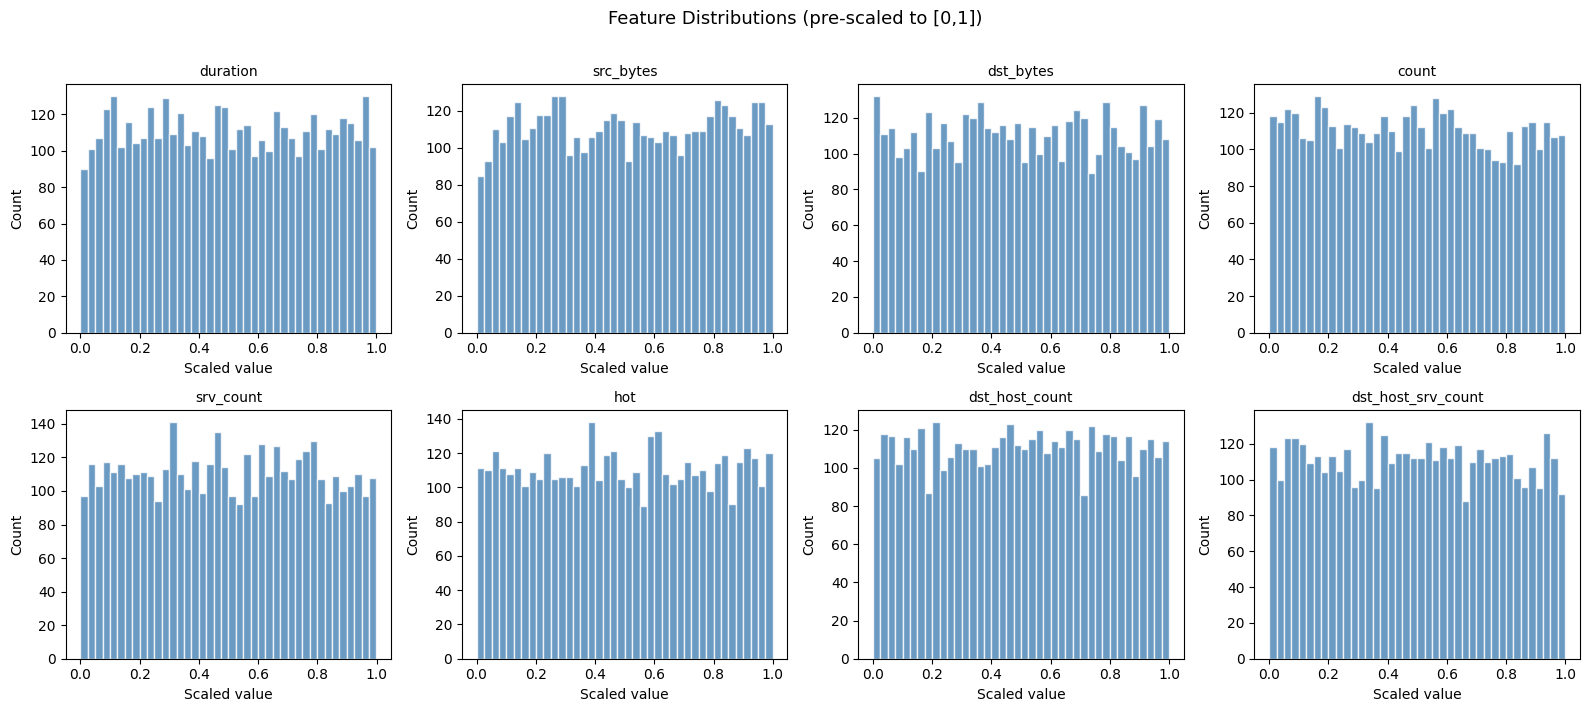

In [5]:
key_feats = ['duration','src_bytes','dst_bytes','count',
             'srv_count','hot','dst_host_count','dst_host_srv_count']
key_feats = [f for f in key_feats if f in df.columns]

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, feat in zip(axes.flatten(), key_feats):
    ax.hist(df[feat], bins=40, color='steelblue', alpha=0.8, edgecolor='white')
    ax.set_title(feat, fontsize=10)
    ax.set_xlabel('Scaled value')
    ax.set_ylabel('Count')
plt.suptitle('Feature Distributions (pre-scaled to [0,1])', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../shared/feature_distributions.png', dpi=150)
plt.show()

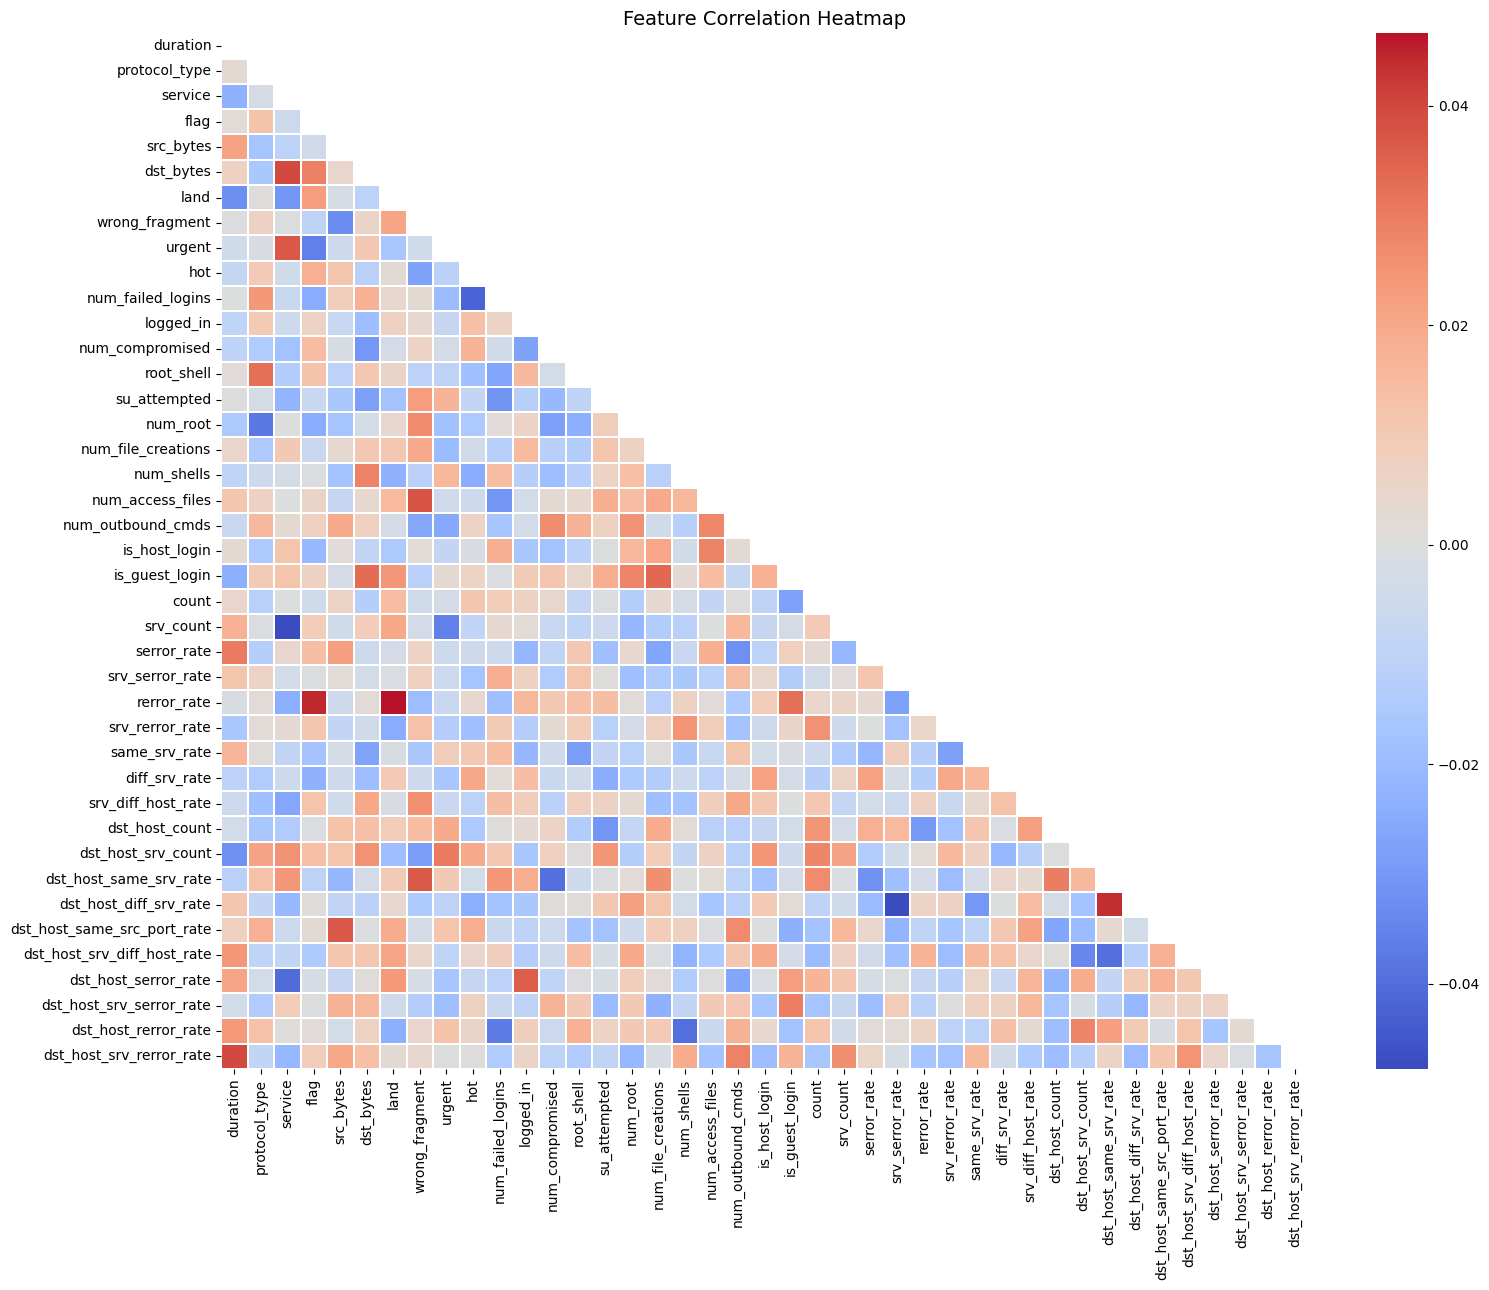

In [6]:
plt.figure(figsize=(16, 13))
mask = np.triu(np.ones_like(df[feature_cols].corr(), dtype=bool))
sns.heatmap(df[feature_cols].corr(), mask=mask, cmap='coolwarm',
            center=0, linewidths=0.2, annot=False)
plt.title('Feature Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.savefig('../shared/correlation_heatmap.png', dpi=150)
plt.show()

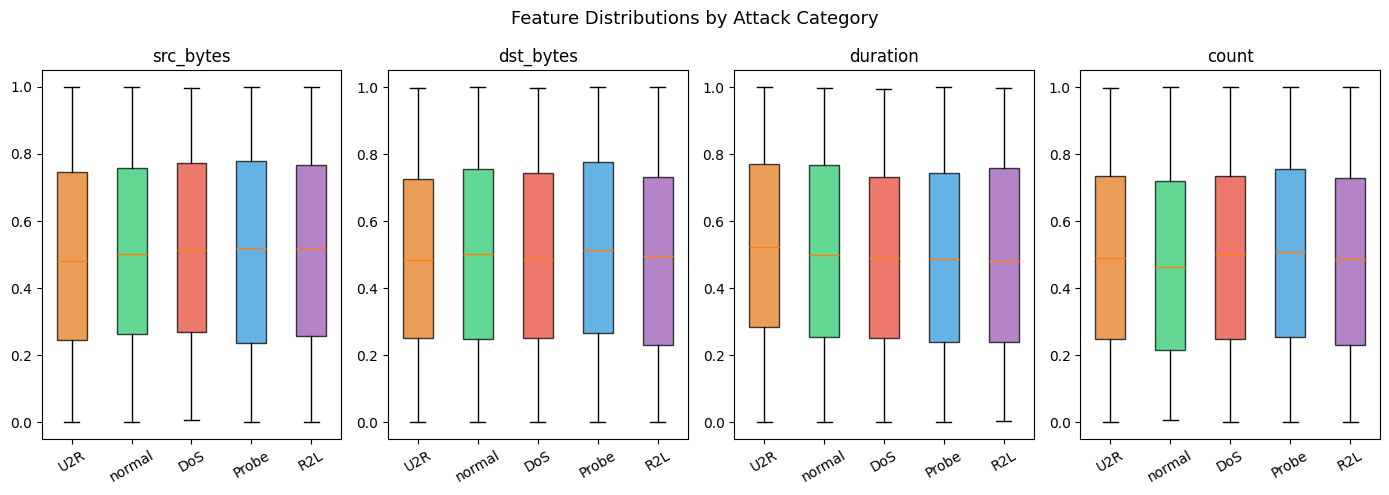

In [7]:
# Boxplot: key features per attack category
plot_feats = ['src_bytes','dst_bytes','duration','count']
plot_feats = [f for f in plot_feats if f in df.columns]
cat_palette = {'normal':'#2ecc71','DoS':'#e74c3c',
               'Probe':'#3498db','R2L':'#9b59b6','U2R':'#e67e22'}
attack_cats = df['label'].unique()

fig, axes = plt.subplots(1, len(plot_feats), figsize=(14, 5))
for ax, feat in zip(axes, plot_feats):
    data_by_cat = [df.loc[df['label']==c, feat].values for c in attack_cats]
    bp = ax.boxplot(data_by_cat, patch_artist=True, labels=attack_cats)
    for patch, cat in zip(bp['boxes'], attack_cats):
        patch.set_facecolor(cat_palette.get(cat,'#95a5a6'))
        patch.set_alpha(0.75)
    ax.set_title(feat)
    ax.tick_params(axis='x', rotation=30)
plt.suptitle('Feature Distributions by Attack Category', fontsize=13)
plt.tight_layout()
plt.savefig('../shared/boxplot_by_attack.png', dpi=150)
plt.show()

## 6. Data Cleaning

In [8]:
before = len(df)
df.drop_duplicates(inplace=True)
print(f'Rows before: {before}  |  After: {len(df)}  |  Removed: {before - len(df)}')

Rows before: 4430  |  After: 4430  |  Removed: 0


## 7. Create Binary Labels

Binary label distribution (full dataset):
binary_label
1    3544
0     886
Name: count, dtype: int64

Attack ratio: 0.8000  (80.0%)

*** Class imbalance detected: ~80% attack vs ~20% normal ***
>>> SMOTE will be applied on the TRAINING SET to fix this.


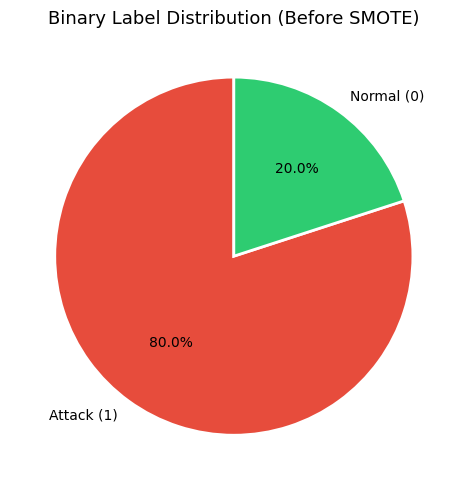

In [9]:
# 0 = normal, 1 = any attack type
df['binary_label'] = df['label'].apply(lambda x: 0 if x == 'normal' else 1)

print('Binary label distribution (full dataset):')
print(df['binary_label'].value_counts())
print(f'\nAttack ratio: {df["binary_label"].mean():.4f}  ({df["binary_label"].mean()*100:.1f}%)')
print('\n*** Class imbalance detected: ~80% attack vs ~20% normal ***')
print('>>> SMOTE will be applied on the TRAINING SET to fix this.')

counts = df['binary_label'].value_counts()
plt.figure(figsize=(6, 5))
plt.pie(counts, labels=['Attack (1)','Normal (0)'],
        autopct='%1.1f%%', colors=['#e74c3c','#2ecc71'],
        startangle=90, wedgeprops={'edgecolor':'white','linewidth':2})
plt.title('Binary Label Distribution (Before SMOTE)', fontsize=13)
plt.tight_layout()
plt.savefig('../shared/binary_label_pie_before_smote.png', dpi=150)
plt.show()

## 8. Train / Test Split (Stratified 80/20)

In [10]:
feature_cols = [c for c in df.columns if c not in ['label','binary_label']]

X = df[feature_cols].values
y = df['binary_label'].values

# Stratify preserves the 80/20 attack ratio in both splits
X_train_raw, X_test, y_train_raw, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f'Total samples        : {len(X)}')
print(f'X_train (raw)        : {X_train_raw.shape} | normal={np.sum(y_train_raw==0)}, attack={np.sum(y_train_raw==1)}')
print(f'X_test  (unchanged)  : {X_test.shape}      | normal={np.sum(y_test==0)}, attack={np.sum(y_test==1)}')
print(f'\nTraining attack ratio: {y_train_raw.mean():.4f} ({y_train_raw.mean()*100:.1f}%)')

Total samples        : 4430
X_train (raw)        : (3544, 41) | normal=709, attack=2835
X_test  (unchanged)  : (886, 41)      | normal=177, attack=709

Training attack ratio: 0.7999 (80.0%)


## 9. SMOTE Oversampling on Training Set
SMOTE creates **synthetic** samples of the minority class (normal=0)
by interpolating between existing normal samples in feature space.
The test set is **never touched** — evaluation stays realistic.

In [11]:
smote = SMOTE(
    sampling_strategy=1.0,  # oversample minority to match majority count
    k_neighbors=5,
    random_state=42
)

X_train, y_train = smote.fit_resample(X_train_raw, y_train_raw)

print('=== After SMOTE ===')
print(f'X_train : {X_train.shape}')
print(f'  Normal (0) : {np.sum(y_train==0)}')
print(f'  Attack (1) : {np.sum(y_train==1)}')
print(f'  Attack ratio: {y_train.mean():.4f} ({y_train.mean()*100:.1f}%)')

=== After SMOTE ===
X_train : (5670, 41)
  Normal (0) : 2835
  Attack (1) : 2835
  Attack ratio: 0.5000 (50.0%)


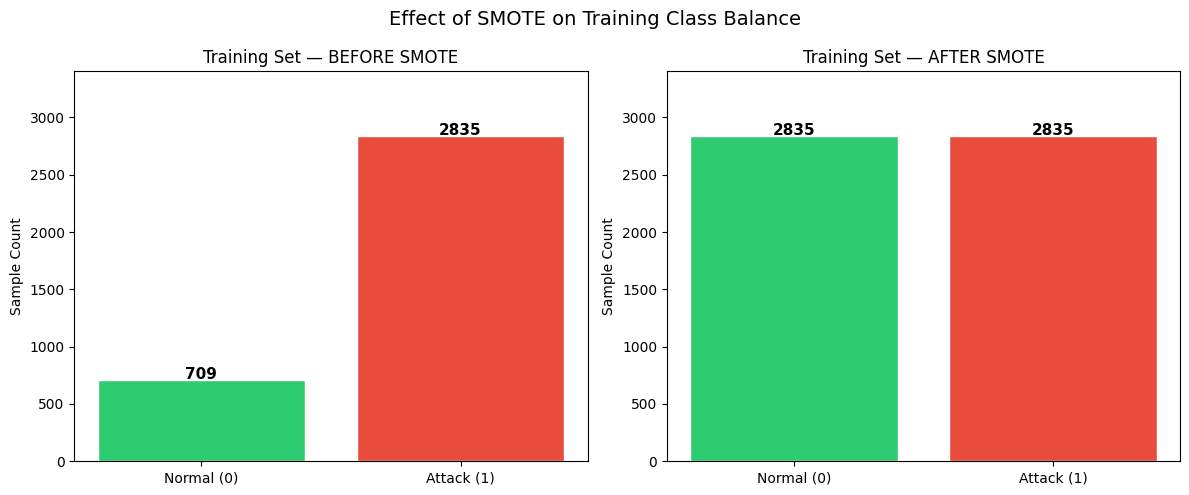

Test set is NOT oversampled — real-world distribution preserved.


In [12]:
# Before vs After comparison chart
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Before
before_counts = pd.Series(y_train_raw).value_counts().sort_index()
axes[0].bar(['Normal (0)','Attack (1)'], before_counts.values,
            color=['#2ecc71','#e74c3c'], edgecolor='white')
for i, v in enumerate(before_counts.values):
    axes[0].text(i, v+10, str(v), ha='center', fontsize=11, fontweight='bold')
axes[0].set_title('Training Set — BEFORE SMOTE', fontsize=12)
axes[0].set_ylabel('Sample Count')
axes[0].set_ylim(0, max(before_counts.values)*1.2)

# After
after_counts = pd.Series(y_train).value_counts().sort_index()
axes[1].bar(['Normal (0)','Attack (1)'], after_counts.values,
            color=['#2ecc71','#e74c3c'], edgecolor='white')
for i, v in enumerate(after_counts.values):
    axes[1].text(i, v+10, str(v), ha='center', fontsize=11, fontweight='bold')
axes[1].set_title('Training Set — AFTER SMOTE', fontsize=12)
axes[1].set_ylabel('Sample Count')
axes[1].set_ylim(0, max(after_counts.values)*1.2)

plt.suptitle('Effect of SMOTE on Training Class Balance', fontsize=14)
plt.tight_layout()
plt.savefig('../shared/smote_before_after.png', dpi=150)
plt.show()
print('Test set is NOT oversampled — real-world distribution preserved.')

## 10. Save All Processed Data

In [13]:
os.makedirs('../data/processed', exist_ok=True)

payload = {
    # SMOTE-balanced training data (use for all model training)
    'X_train'      : X_train,
    'y_train'      : y_train,
    # Raw test data (never oversampled)
    'X_test'       : X_test,
    'y_test'       : y_test,
    # Metadata
    'feature_cols' : feature_cols,
    'attack_ratio' : float(y_train_raw.mean()),   # original ratio before SMOTE
    'df_full'      : df
}

with open('../data/processed/preprocessed_data.pkl', 'wb') as f:
    pickle.dump(payload, f)

print('Saved: ../data/processed/preprocessed_data.pkl')
print()
print('=== FINAL SUMMARY ===')
print(f'  Total rows          : {len(df)}')
print(f'  Features            : {len(feature_cols)}')
print(f'  X_train (SMOTE)     : {X_train.shape}  — balanced 50/50')
print(f'  X_test  (real-world): {X_test.shape}')
print(f'  Feature range       : [{X_train.min():.4f}, {X_train.max():.4f}]')
print()
print('All member notebooks can now load preprocessed_data.pkl')

Saved: ../data/processed/preprocessed_data.pkl

=== FINAL SUMMARY ===
  Total rows          : 4430
  Features            : 41
  X_train (SMOTE)     : (5670, 41)  — balanced 50/50
  X_test  (real-world): (886, 41)
  Feature range       : [0.0000, 1.0000]

All member notebooks can now load preprocessed_data.pkl
